## Individual Project - Victoria Wen

## Proposal
**Research Domain**: Cognitive neuroscience & psychology (semantic representations)

**Research Background**:
- Before deep learning and embeddings became common, most sentiment models used bag-of-words or **TF-IDF** representations.

- **Ramdan, D. S., & Apnena, R. D. (2023).**
  - Demonstrates that TF-IDF features combined with logistic regression can successfully classify movie reviews into positive and negative sentiment.
- **Socher, R., Perelygin, A., Wu, J., et al. (2013/2014).**  
  - Introduced the **Stanford Sentiment Treebank (SST)**, a benchmark dataset designed to study human sentiment judgments at the sentence level and widely used for evaluating sentiment classification models.  
  - (Socher et al., 2013) [https://aclanthology.org/D13-1170/]

- **Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019).**  
  - Demonstrates that **pretrained contextual embeddings** capture rich semantic and affective information that can be leveraged for downstream tasks such as sentiment classification.  
  - (Devlin et al., 2019) [https://aclanthology.org/N19-1423/]

- **Reimers, N., & Gurevych, I. (2019).**  
  - Introduces **Sentence-BERT**, showing that sentence-level embeddings are effective for semantic similarity and clustering tasks, supporting the representation framework used in this project.  
  - (Reimers & Gurevych, 2019) [https://aclanthology.org/D19-1410/]


**Research Questions**: Do semantic embeddings capture human sentiment judgments better than lexical features? Do sentiments emerge in unsupervised clusters?

**Hypothesis**: Embeddings are more effective for human sentiment judgments better than lexical features, and sentiments will emerge in unsupervised clusters.




**Data Source**
- **Stanford Sentiment Treebank (SST)**  
  - Data source: [https://nlp.stanford.edu/sentiment/](https://nlp.stanford.edu/sentiment/)  
  - Contains **sentence-level movie reviews annotated for sentiment**, widely used for evaluating sentiment classification models.  
  - **Data size:** 215,154 phrases extracted from the parse trees of 11,855 sentences.  
  - After preprocessing and filtering out neutral or ambiguous cases, the resulting datasets are analyzed separately using the same modeling pipeline to ensure consistent comparison across representations.  
  - (Socher et al., 2013)

**Models & Evaluation**

• Models: Logistic Regression (L1 / L2 regularization), Unsupervised Clustering  
• Representations: TF-IDF (lexical) vs Sentence Embeddings (semantic)  
• Metrics: Balanced Accuracy, Macro-F1, Confusion Matrix  
• Error analysis: Inspect misclassified sentences  


**Expected Contribution**

A quantitative comparison of **lexical vs semantic representations** in predicting human sentiment judgments.

The project examines whether **surface lexical features (TF-IDF)** or **semantic sentence embeddings** better capture sentiment structure.


**Further Direction**

Compare the two representations on:

• **Prediction performance** on sentiment classification  
• **Error patterns** in misclassified sentences  
• **Unsupervised clustering** in embedding space (whether sentiment structure emerges without labels)

## EDA Process
### 1. Set up and loading data

In [3]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix

In [4]:

DATA_DIR = "stanfordSentimentTreebank"  
paths = {
    "sentences": os.path.join(DATA_DIR, "datasetSentences.txt"),
    "split": os.path.join(DATA_DIR, "datasetSplit.txt"),
    "dictionary": os.path.join(DATA_DIR, "dictionary.txt"),
    "sentiment_labels": os.path.join(DATA_DIR, "sentiment_labels.txt"),
    "sostr": os.path.join(DATA_DIR, "SOStr.txt"),
}



### 2. Get sentence df and split df 

In [5]:
sent_df = pd.read_csv(paths["sentences"], sep="\t", header=0)
sent_df.columns = ["sentence_index", "sentence"]
sent_df["sentence_index"] = sent_df["sentence_index"].astype(int)

split_df = pd.read_csv(paths["split"], sep=",", header=0)
split_df.columns = ["sentence_index", "split_label"]

split_df["sentence_index"] = split_df["sentence_index"].astype(int)
split_df["split"] = split_df["split_label"].map({1:"train", 2:"test", 3:"dev"})

df = sent_df.merge(split_df[["sentence_index","split"]], on="sentence_index", how="left")
print("Total sentences:", len(df))
print(df["split"].value_counts(dropna=False))
df.head()

Total sentences: 11855
split
train    8544
test     2210
dev      1101
Name: count, dtype: int64


,sentence_index,sentence,split
0,1,The Rock is destined to be the 21st Century 's...,train
1,2,The gorgeously elaborate continuation of `` Th...,train
2,3,Effective but too-tepid biopic,test
3,4,If you sometimes like to go to the movies to h...,test
4,5,"Emerges as something rare , an issue movie tha...",test


### 3. Get Phrase ID and sentiment labels

In [6]:
dict_df = pd.read_csv(paths["dictionary"], sep=r"\|", header=None, engine="python")
dict_df.columns = ["phrase", "phrase_id"]
dict_df["phrase_id"] = dict_df["phrase_id"].astype(int)

lab_df = pd.read_csv(paths["sentiment_labels"], sep=r"\|", header=0, engine="python")
lab_df.columns = ["phrase_id", "sentiment"]
lab_df["phrase_id"] = lab_df["phrase_id"].astype(int)
lab_df["sentiment"] = lab_df["sentiment"].astype(float)

phrase2id = dict(zip(dict_df["phrase"], dict_df["phrase_id"]))
id2sent = dict(zip(lab_df["phrase_id"], lab_df["sentiment"]))

print("Dictionary size:", len(dict_df))
print("Label table size:", len(lab_df))
lab_df["sentiment"].describe()

Dictionary size: 239232
Label table size: 239232


count    239232.000000
mean          0.513001
std           0.175356
min           0.000000
25%           0.416670
50%           0.500000
75%           0.611110
max           1.000000
Name: sentiment, dtype: float64

In [7]:
phrase2id = dict(zip(dict_df["phrase"], dict_df["phrase_id"]))
id2sent = dict(zip(lab_df["phrase_id"], lab_df["sentiment"]))

### 4. Map sentence → sentiment score (with SOStr fallback)
Why?: Sometimes the raw sentence string doesn’t match the tokenized phrase stored in dictionary.txt. SOStr.txt provides the tokenized version.

In [8]:
with open(paths["sostr"], "r", encoding="utf-8") as f:
    sostr_lines = [line.strip() for line in f.readlines()]

def sostr_for_index(i: int) -> str:
    # sentence_index is 1-indexed
    if 1 <= i <= len(sostr_lines):
        return sostr_lines[i-1].replace("|", " ").strip()
    return None

df["sostr"] = df["sentence_index"].apply(sostr_for_index)

def lookup_sentiment(raw_sentence: str, sostr_sentence: str):
    pid = phrase2id.get(raw_sentence)
    if pid is None and sostr_sentence is not None:
        pid = phrase2id.get(sostr_sentence)
    if pid is None:
        return np.nan
    return id2sent.get(pid, np.nan)

df["sentiment_score"] = df.apply(lambda r: lookup_sentiment(r["sentence"], r["sostr"]), axis=1)

coverage = df["sentiment_score"].notna().mean()
print(f"Sentence-level sentiment mapping coverage: {coverage:.4f}")

# Show a few unmapped examples (if any)
df[df["sentiment_score"].isna()][["sentence_index","sentence","sostr","split"]].head(10)

Sentence-level sentiment mapping coverage: 1.0000


,sentence_index,sentence,sostr,split


### 5. Basic Dataset Overview

In [9]:
print("Split counts:")
print(df["split"].value_counts())

print("\nSentiment score summary (mapped only):")
print(df["sentiment_score"].dropna().describe())

Split counts:
split
train    8544
test     2210
dev      1101
Name: count, dtype: int64

Sentiment score summary (mapped only):
count    11855.000000
mean         0.510351
std          0.252324
min          0.000000
25%          0.277780
50%          0.500000
75%          0.736110
max          1.000000
Name: sentiment_score, dtype: float64


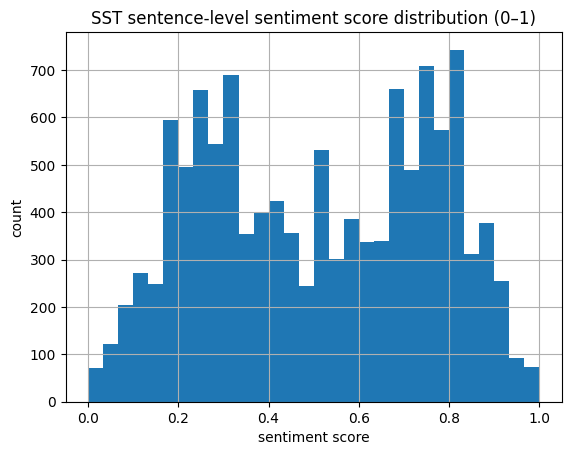

In [10]:
#sentiment score distribution
plt.figure()
df["sentiment_score"].dropna().hist(bins=30)
plt.title("SST sentence-level sentiment score distribution (0–1)")
plt.xlabel("sentiment score")
plt.ylabel("count")
plt.show()

In [11]:
# Show a few examples per split
for sp in ["train","dev","test"]:
    print("\n=== Examples:", sp, "===")
    display(df[df["split"]==sp][["sentence","sentiment_score"]].head(5))


=== Examples: train ===


,sentence,sentiment_score
0,The Rock is destined to be the 21st Century 's...,0.69444
1,The gorgeously elaborate continuation of `` Th...,0.83333
60,Singer\/composer Bryan Adams contributes a sle...,0.62500
61,You 'd think by now America would have had eno...,0.50000
62,Yet the act is still charming here .,0.72222



=== Examples: dev ===


,sentence,sentiment_score
1116,It 's a lovely film with lovely performances b...,0.79167
1117,"No one goes unindicted here , which is probabl...",0.51389
1118,And if you 're not nearly moved to tears by a ...,0.76389
1119,"A warm , funny , engaging film .",0.88889
1120,Uses sharp humor and insight into human nature...,0.80556



=== Examples: test ===


,sentence,sentiment_score
2,Effective but too-tepid biopic,0.51389
3,If you sometimes like to go to the movies to h...,0.73611
4,"Emerges as something rare , an issue movie tha...",0.86111
5,The film provides some great insight into the ...,0.59722
6,Offers that rare combination of entertainment ...,0.83333


## Build the dataset

### Create Labels - 5 classes + binary SST-2

Sentiment scores are converted into binary labels following the SST-2 setting. Sentences with sentiment scores ≤ 0.4 were labeled as negative and those ≥ 0.6 were labeled as positive. Sentences with scores between 0.4 and 0.6 were treated as neutral or ambiguous and removed from the dataset.

In [12]:
def to_5class(s):
    if pd.isna(s): 
        return np.nan
    if s <= 0.2: return "very_neg"
    if s <= 0.4: return "neg"
    if s <  0.6: return "neutral"
    if s <= 0.8: return "pos"
    return "very_pos"

def to_binary(s):
    if pd.isna(s): 
        return np.nan
    if s <= 0.4: return 0  # negative
    if s >= 0.6: return 1  # positive
    return np.nan          # neutral/ambiguous -> drop

df["label_5"] = df["sentiment_score"].apply(to_5class)
df["label_bin"] = df["sentiment_score"].apply(to_binary)

df_bin = df.dropna(subset=["label_bin"]).copy()
df_bin["label_bin"] = df_bin["label_bin"].astype(int)

print("Binary (SST-2 style) size:", len(df_bin))
print("Class balance (overall):")
print(df_bin["label_bin"].value_counts())
print("\nClass balance by split:")
print(pd.crosstab(df_bin["split"], df_bin["label_bin"]))

Binary (SST-2 style) size: 9612
Class balance (overall):
label_bin
1    4962
0    4650
Name: count, dtype: int64

Class balance by split:
label_bin     0     1
split                
dev         428   444
test        912   908
train      3310  3610


In [13]:
def simple_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", str(text).lower())

df_bin["n_tokens"] = df_bin["sentence"].apply(lambda x: len(simple_tokenize(x)))
df_bin["n_chars"] = df_bin["sentence"].astype(str).apply(len)

df_bin[["n_tokens","n_chars"]].describe()


,n_tokens,n_chars
count,9612.000000,9612.000000
mean,20.956097,103.809717
std,10.124763,50.866494
min,2.000000,5.000000
25%,13.000000,64.000000
50%,20.000000,100.000000
75%,28.000000,138.000000
max,64.000000,283.000000


In [14]:
print(df_bin.groupby("label_bin")["n_tokens"].describe())

            count       mean        std  min   25%   50%   75%   max
label_bin                                                           
0          4650.0  20.909247  10.092727  2.0  13.0  20.0  28.0  62.0
1          4962.0  21.000000  10.155513  2.0  13.0  20.0  28.0  64.0


In [15]:
train_text = df_bin[df_bin["split"]=="train"]["sentence"].tolist()
dev_text   = df_bin[df_bin["split"]=="dev"]["sentence"].tolist()
test_text  = df_bin[df_bin["split"]=="test"]["sentence"].tolist()

y_train = df_bin[df_bin["split"]=="train"]["label_bin"].values
y_dev   = df_bin[df_bin["split"]=="dev"]["label_bin"].values
y_test  = df_bin[df_bin["split"]=="test"]["label_bin"].values

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=20000, min_df=2)
X_train_tfidf = vectorizer.fit_transform(train_text)
X_dev_tfidf   = vectorizer.transform(dev_text)
X_test_tfidf  = vectorizer.transform(test_text)

print("TF-IDF shapes:", X_train_tfidf.shape, X_dev_tfidf.shape, X_test_tfidf.shape)
nnz = X_train_tfidf.nnz
total = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
sparsity = 1 - (nnz / total)
print(f"Train TF-IDF sparsity: {sparsity:.4f}")
print("Vocab size:", len(vectorizer.vocabulary_))

TF-IDF shapes: (6920, 18373) (872, 18373) (1820, 18373)
Train TF-IDF sparsity: 0.9988
Vocab size: 18373


## Model training

In [16]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)

def eval_clf(name, clf, X_train, y_train, X_dev, y_dev, X_test, y_test):
    def _one_split(split_name, X, y):
        yhat = clf.predict(X)
        return {
            "model": name,
            "split": split_name,
            "accuracy": accuracy_score(y, yhat),
            "balanced_accuracy": balanced_accuracy_score(y, yhat),
            "macro_f1": f1_score(y, yhat, average="macro"),
            "confusion_matrix": confusion_matrix(y, yhat)
        }

    rows = [
        _one_split("train", X_train, y_train),
        _one_split("dev",   X_dev,   y_dev),
        _one_split("test",  X_test,  y_test),
    ]
    return pd.DataFrame(rows)

def print_reports(clf, X_dev, y_dev, X_test, y_test):
    print("DEV report:")
    print(classification_report(y_dev, clf.predict(X_dev), digits=3))
    print("\nTEST report:")
    print(classification_report(y_test, clf.predict(X_test), digits=3))

### TFIDF + Logistic Regression

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Safety checks
assert {"sentence","split","label_bin"}.issubset(df_bin.columns)

train_text = df_bin[df_bin["split"]=="train"]["sentence"].tolist()
dev_text   = df_bin[df_bin["split"]=="dev"]["sentence"].tolist()
test_text  = df_bin[df_bin["split"]=="test"]["sentence"].tolist()

y_train = df_bin[df_bin["split"]=="train"]["label_bin"].values
y_dev   = df_bin[df_bin["split"]=="dev"]["label_bin"].values
y_test  = df_bin[df_bin["split"]=="test"]["label_bin"].values

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        max_features=20000
    )),
    ("lr", LogisticRegression(max_iter=3000, random_state=0))
])

param_grid = {
    "lr__penalty": ["l2", "l1"],
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__solver": ["liblinear", "saga"],  # both support l1/l2 for binary
}

grid_tfidf_lr = GridSearchCV(
    tfidf_lr,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_tfidf_lr.fit(train_text, y_train)
print("Best TF-IDF LR params:", grid_tfidf_lr.best_params_)
print("Best CV balanced acc:", grid_tfidf_lr.best_score_)

best_tfidf_lr = grid_tfidf_lr.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best TF-IDF LR params: {'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'saga'}
Best CV balanced acc: 0.7885966307085889


In [18]:
# Evaluate
res_tfidf_lr = eval_clf(
    "TFIDF + LogisticRegression",
    best_tfidf_lr,
    train_text, y_train,
    dev_text, y_dev,
    test_text, y_test
)
res_tfidf_lr

,model,split,accuracy,balanced_accuracy,macro_f1,confusion_matrix
0,TFIDF + LogisticRegression,train,0.998699,0.998728,0.998697,"[[3308, 2], [7, 3603]]"
1,TFIDF + LogisticRegression,dev,0.793578,0.793045,0.793185,"[[327, 101], [79, 365]]"
2,TFIDF + LogisticRegression,test,0.812088,0.812126,0.812043,"[[725, 187], [155, 753]]"


In [19]:
def show_top_features_tfidf_lr(pipeline, top_n=20):
    # Extract vectorizer and classifier
    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["lr"]
    
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = clf.coef_[0]  # binary classification
    
    # Sort indices
    top_positive_idx = np.argsort(coefs)[-top_n:][::-1]
    top_negative_idx = np.argsort(coefs)[:top_n]
    
    print(f"\nTop {top_n} Positive Features:\n")
    for idx in top_positive_idx:
        print(f"{feature_names[idx]:<25} {coefs[idx]:.4f}")
    
    print(f"\nTop {top_n} Negative Features:\n")
    for idx in top_negative_idx:
        print(f"{feature_names[idx]:<25} {coefs[idx]:.4f}")

# Run it
show_top_features_tfidf_lr(best_tfidf_lr, top_n=20)


Top 20 Positive Features:

fun                       5.9571
entertaining              5.2677
solid                     5.2393
powerful                  5.2163
remarkable                4.8969
hilarious                 4.7295
works                     4.6934
funny                     4.5813
love                      4.5062
enjoyable                 4.4722
and                       4.4536
fascinating               4.3649
wonderful                 4.3434
refreshing                4.2488
definitely                4.1729
terrific                  4.1557
the best                  4.1256
beautiful                 4.1224
not too                   4.1184
smart                     4.0828

Top 20 Negative Features:

bad                       -6.5042
too                       -6.3371
dull                      -5.5523
stupid                    -5.1846
the worst                 -4.7693
mess                      -4.7086
only                      -4.6699
feels                     -4.5376
no          

### TFIDF + Decision Tree

Here we add a decision tree analysis for comparison.

In [20]:
from sklearn.tree import DecisionTreeClassifier

tfidf_dt = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        max_features=20000
    )),
    ("dt", DecisionTreeClassifier(random_state=0))
])

param_grid_dt = {
    "dt__max_depth": [3, 5, 10, None],
    "dt__min_samples_split": [2, 5, 10],
    "dt__criterion": ["gini", "entropy"],
}

grid_tfidf_dt = GridSearchCV(
    tfidf_dt,
    param_grid=param_grid_dt,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_tfidf_dt.fit(train_text, y_train)
print("Best TF-IDF DT params:", grid_tfidf_dt.best_params_)
print("Best CV balanced acc:", grid_tfidf_dt.best_score_)

best_tfidf_dt = grid_tfidf_dt.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best TF-IDF DT params: {'dt__criterion': 'entropy', 'dt__max_depth': None, 'dt__min_samples_split': 10}
Best CV balanced acc: 0.6132461859052146


In [21]:
res_tfidf_dt = eval_clf(
    "TFIDF + DecisionTree",
    best_tfidf_dt,
    train_text, y_train,
    dev_text, y_dev,
    test_text, y_test
)
res_tfidf_dt

,model,split,accuracy,balanced_accuracy,macro_f1,confusion_matrix
0,TFIDF + DecisionTree,train,0.965029,0.965741,0.965006,"[[3251, 59], [183, 3427]]"
1,TFIDF + DecisionTree,dev,0.631881,0.631652,0.631667,"[[265, 163], [158, 286]]"
2,TFIDF + DecisionTree,test,0.642857,0.642848,0.642846,"[[590, 322], [328, 580]]"


### Sentence Embeddings 

In [22]:

# !pip -q install sentence-transformers

import os
import numpy as np

EMB_CACHE_DIR = "cache_embeddings"
os.makedirs(EMB_CACHE_DIR, exist_ok=True)

train_emb_path = os.path.join(EMB_CACHE_DIR, "train_emb.npy")
dev_emb_path   = os.path.join(EMB_CACHE_DIR, "dev_emb.npy")
test_emb_path  = os.path.join(EMB_CACHE_DIR, "test_emb.npy")

def load_or_make_embeddings(texts, path, model_name="all-MiniLM-L6-v2", batch_size=64):
    if os.path.exists(path):
        return np.load(path)
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name)
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )
    np.save(path, emb)
    return emb

X_train_emb = load_or_make_embeddings(train_text, train_emb_path)
X_dev_emb   = load_or_make_embeddings(dev_text,   dev_emb_path)
X_test_emb  = load_or_make_embeddings(test_text,  test_emb_path)

X_train_emb.shape, X_dev_emb.shape, X_test_emb.shape

((6920, 384), (872, 384), (1820, 384))

### Embedding + Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=5000, random_state=0)

param_grid_lr_emb = {
    "penalty": ["l2", "l1"],
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "saga"],
}

grid_emb_lr = GridSearchCV(
    lr,
    param_grid=param_grid_lr_emb,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_emb_lr.fit(X_train_emb, y_train)
print("Best EMB LR params:", grid_emb_lr.best_params_)
print("Best CV balanced acc:", grid_emb_lr.best_score_)

best_emb_lr = grid_emb_lr.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best EMB LR params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV balanced acc: 0.8037781088115423


In [24]:
res_emb_lr = eval_clf(
    "SBERT + LogisticRegression",
    best_emb_lr,
    X_train_emb, y_train,
    X_dev_emb, y_dev,
    X_test_emb, y_test
)
res_emb_lr

,model,split,accuracy,balanced_accuracy,macro_f1,confusion_matrix
0,SBERT + LogisticRegression,train,0.824855,0.824551,0.824534,"[[2706, 604], [608, 3002]]"
1,SBERT + LogisticRegression,dev,0.811927,0.811905,0.811878,"[[347, 81], [83, 361]]"
2,SBERT + LogisticRegression,test,0.813187,0.813229,0.813129,"[[724, 188], [152, 756]]"


### Embedding + Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=0)

param_grid_dt_emb = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_emb_dt = GridSearchCV(
    dt,
    param_grid=param_grid_dt_emb,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_emb_dt.fit(X_train_emb, y_train)
print("Best EMB DT params:", grid_emb_dt.best_params_)
print("Best CV balanced acc:", grid_emb_dt.best_score_)

best_emb_dt = grid_emb_dt.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best EMB DT params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best CV balanced acc: 0.6614263835770058


## Unsupervised: K means on Embeddings

### With Elbow Method

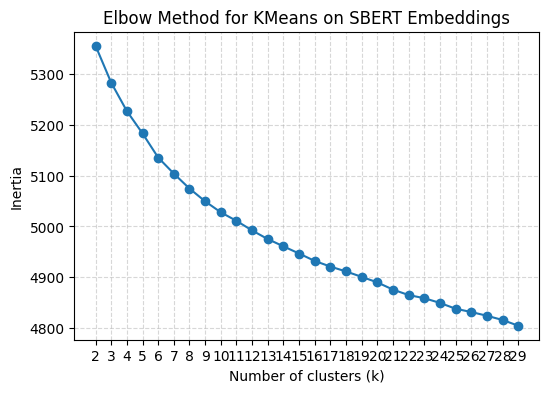

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

# Normalize embeddings
X_train_norm = normalize(X_train_emb)

# Elbow search
ks = range(2, 30)
inertias = []

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )
    km.fit(X_train_norm)
    inertias.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans on SBERT Embeddings")
plt.xticks(ks)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import adjusted_rand_score

def cluster_purity(y_true, cluster_labels):
    # purity = sum_k max_j |C_k ∩ class_j| / N
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)
    total = 0
    for k in np.unique(cluster_labels):
        idx = np.where(cluster_labels == k)[0]
        if len(idx) == 0:
            continue
        counts = np.bincount(y_true[idx].astype(int), minlength=2)
        total += counts.max()
    return total / len(y_true)

# Normalize embeddings (common for clustering in embedding space)
X_train_norm = normalize(X_train_emb)
X_dev_norm   = normalize(X_dev_emb)
X_test_norm  = normalize(X_test_emb)

kmeans = KMeans(n_clusters=2, init="k-means++", n_init=20, random_state=0)
kmeans.fit(X_train_norm)

dev_clusters  = kmeans.predict(X_dev_norm)
test_clusters = kmeans.predict(X_test_norm)

dev_purity  = cluster_purity(y_dev, dev_clusters)
test_purity = cluster_purity(y_test, test_clusters)

dev_ari  = adjusted_rand_score(y_dev, dev_clusters)
test_ari = adjusted_rand_score(y_test, test_clusters)

print("DEV purity:", dev_purity, "DEV ARI:", dev_ari)
print("TEST purity:", test_purity, "TEST ARI:", test_ari)

DEV purity: 0.5355504587155964 DEV ARI: 0.003914362107797592
TEST purity: 0.5285714285714286 TEST ARI: 0.0027194136516907105


DEV Purity: 0.5356
DEV ARI:    0.0039
Confusion matrix (rows=true label 0/1, cols=cluster 0/1):
[[241 187]
 [218 226]]


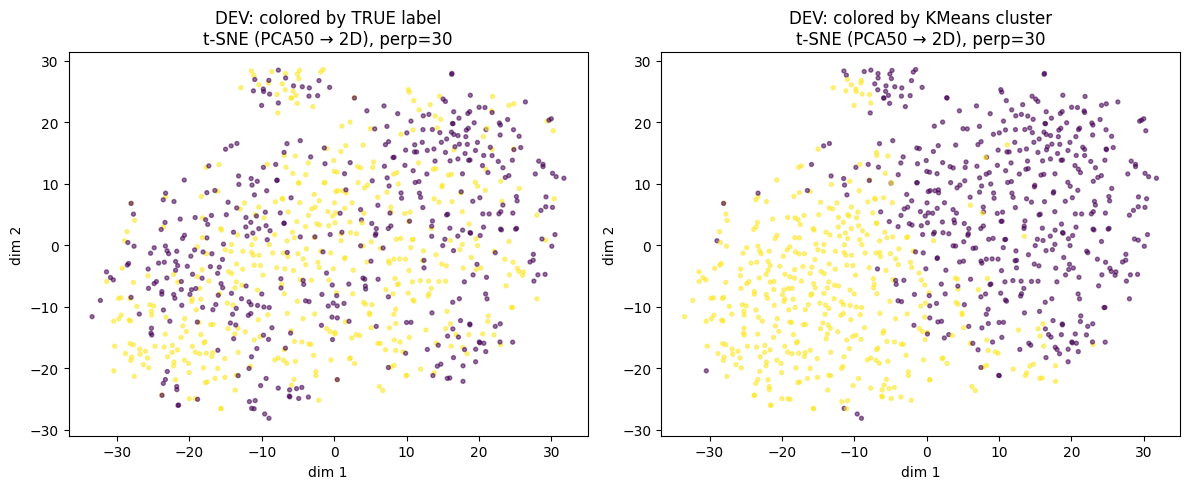

In [49]:
# --- Unsupervised visualization (KMeans on SBERT embeddings) ---


import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.metrics import adjusted_rand_score, confusion_matrix

def _plot_2d(ax, X2, color, title, alpha=0.55, s=8):
    ax.scatter(X2[:, 0], X2[:, 1], c=color, alpha=alpha, s=s)
    ax.set_title(title)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

def _purity(y_true, cluster_labels):
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)
    total = 0
    for k in np.unique(cluster_labels):
        idx = np.where(cluster_labels == k)[0]
        if len(idx) == 0:
            continue
        counts = np.bincount(y_true[idx].astype(int), minlength=2)
        total += counts.max()
    return total / len(y_true)

def visualize_kmeans_unsup(
    X_train_emb, X_dev_emb, y_dev, kmeans,
    use_tsne=True, pca_first_dim=50, tsne_perplexity=30, random_state=0
):
    # Normalize embeddings for nicer geometry
    X_train = normalize(X_train_emb)
    X_dev   = normalize(X_dev_emb)

    # Cluster on DEV
    dev_clusters = kmeans.predict(X_dev)

    # Quant metrics
    pur = _purity(y_dev, dev_clusters)
    ari = adjusted_rand_score(y_dev, dev_clusters)
    cm  = confusion_matrix(y_dev, dev_clusters)

    print(f"DEV Purity: {pur:.4f}")
    print(f"DEV ARI:    {ari:.4f}")
    print("Confusion matrix (rows=true label 0/1, cols=cluster 0/1):")
    print(cm)

    # Dim reduction for plotting
    if use_tsne:
        # PCA -> t-SNE is standard for speed/stability
        pca50 = PCA(n_components=min(pca_first_dim, X_train.shape[1]), random_state=random_state)
        X_train_50 = pca50.fit_transform(X_train)
        X_dev_50   = pca50.transform(X_dev)

        tsne = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )
        X_dev_2 = tsne.fit_transform(X_dev_50)
        method = f"t-SNE (PCA{pca_first_dim} → 2D), perp={tsne_perplexity}"
    else:
        pca2 = PCA(n_components=2, random_state=random_state)
        X_dev_2 = pca2.fit_transform(X_dev)
        method = "PCA (2D)"

    # Plot: color by (a) true label, (b) cluster assignment
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    _plot_2d(axes[0], X_dev_2, y_dev,         f"DEV: colored by TRUE label\n{method}")
    _plot_2d(axes[1], X_dev_2, dev_clusters,  f"DEV: colored by KMeans cluster\n{method}")
    plt.tight_layout()
    plt.show()

# ---- Run it ----

visualize_kmeans_unsup(
    X_train_emb=X_train_emb,
    X_dev_emb=X_dev_emb,
    y_dev=y_dev,
    kmeans=kmeans,
    use_tsne=True,          
    pca_first_dim=50,
    tsne_perplexity=30,
    random_state=0
)

### Error Analysis
#### For Tf-idf

In [50]:
import pandas as pd
import numpy as np

def get_misclassified_examples(pipeline, X_text, y_true):
    y_pred = pipeline.predict(X_text)
    probs = pipeline.predict_proba(X_text)[:, 1]  # prob of positive class
    
    df_errors = pd.DataFrame({
        "sentence": X_text,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_positive": probs
    })
    
    df_errors["correct"] = df_errors["true_label"] == df_errors["pred_label"]
    
    misclassified = df_errors[df_errors["correct"] == False].copy()
    
    return misclassified.sort_values("prob_positive")


# Run on dev
mis_dev = get_misclassified_examples(best_tfidf_lr, dev_text, y_dev)
# mis_dev.head(10)



In [51]:
## Eror analysis function for both models

def get_misclassified_examples(model, X, y_true, sentences=None):
    """
    model: classifier with predict and predict_proba
    X: features (list of strings for TF-IDF pipeline, OR np array for embeddings)
    y_true: 1D labels
    sentences: list of raw sentences (required if X is embeddings)
    """
    y_true = np.asarray(y_true).ravel()  # ensure 1D

    y_pred = model.predict(X)
    probs = model.predict_proba(X)[:, 1]  # 1D prob of positive

    if sentences is None:
        # assume X itself is raw text (list/Series of strings)
        sentences = X
    else:
        # ensure it's 1D list of strings
        sentences = list(sentences)

    df_errors = pd.DataFrame({
        "sentence": sentences,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_positive": probs
    })

    misclassified = df_errors[df_errors["true_label"] != df_errors["pred_label"]].copy()
    return misclassified.sort_values("prob_positive")

In [52]:
mis_dev_tfidf = get_misclassified_examples(best_tfidf_lr, dev_text, y_dev)
mis_dev_tfidf.head()

,sentence,true_label,pred_label,prob_positive
247,As unseemly as its title suggests .,1,0,0.036699
392,A taut psychological thriller that does n't wa...,1,0,0.043937
192,It seems like I have been waiting my whole lif...,1,0,0.069085
185,My thoughts were focused on the characters .,1,0,0.071410
224,"A full world has been presented onscreen , not...",1,0,0.107048


In [53]:
mis_dev_emb = get_misclassified_examples(best_emb_lr, X_dev_emb, y_dev, sentences=dev_text)
mis_dev_emb.head()

,sentence,true_label,pred_label,prob_positive
308,But it still jingles in the pocket .,1,0,0.057554
253,No screen fantasy-adventure in recent memory h...,1,0,0.058452
101,Turns potentially forgettable formula into som...,1,0,0.059548
507,A working class `` us vs. them '' opera that l...,1,0,0.060812
395,"The jabs it employs are short , carefully plac...",1,0,0.070693


### Confusion matrix

In [54]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, X, y_true, title="", labels=(0, 1), normalize=None):
    """
    normalize: None | 'true' | 'pred' | 'all'
      - None: raw counts
      - 'true': row-normalized (recall per class)
      - 'pred': col-normalized (precision per class)
      - 'all': normalized by total
    """
    y_pred = model.predict(X)
    cm = confusion_matrix(y_true, y_pred, labels=list(labels), normalize=normalize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(labels))
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2f" if normalize else "d",
        colorbar=False
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    plt.show()
    return cm

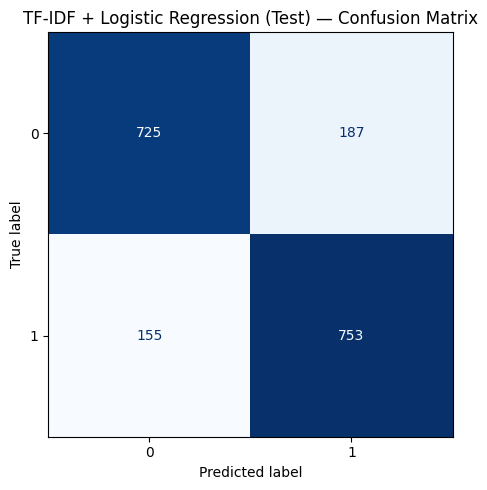

array([[725, 187],
       [155, 753]])

In [55]:
# 0 = NEG, 1 = POS
plot_confusion_matrix(
    best_tfidf_lr,
    test_text,
    y_test,
    title="TF-IDF + Logistic Regression (Test) — Confusion Matrix",
    labels=(0, 1),
    normalize=None   # use 'true' for row-normalized
)

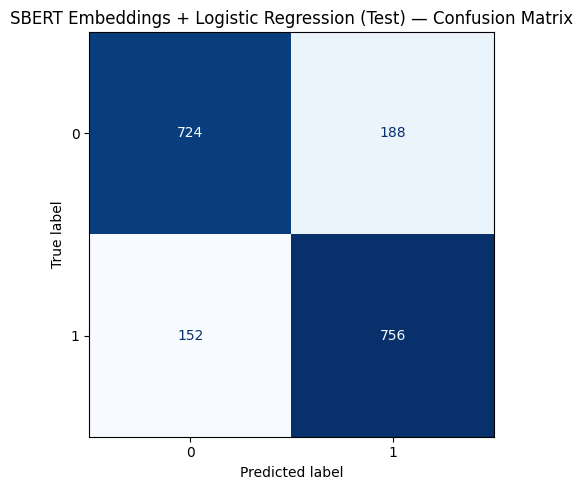

array([[724, 188],
       [152, 756]])

In [56]:
plot_confusion_matrix(
    best_emb_lr,
    X_test_emb,
    y_test,
    title="SBERT Embeddings + Logistic Regression (Test) — Confusion Matrix",
    labels=(0, 1),
    normalize=None
)


### TF-IDF False Positives Examples

In [57]:
# False positives: true 0, predicted 1 (high prob_positive)
false_pos_tfidf = mis_dev_tfidf[mis_dev_tfidf["true_label"] == 0].sort_values("prob_positive", ascending=False)

for _, row in false_pos_tfidf.head(10).iterrows():
    print("Sentence:", row["sentence"])
    print("TRUE: NEG | PRED: POS | prob_pos:", round(row["prob_positive"], 3))
    print("-"*60)

Sentence: However it may please those who love movies that blare with pop songs , young science fiction fans will stomp away in disgust .
TRUE: NEG | PRED: POS | prob_pos: 0.978
------------------------------------------------------------
Sentence: Outer-space buffs might love this film , but others will find its pleasures intermittent .
TRUE: NEG | PRED: POS | prob_pos: 0.965
------------------------------------------------------------
Sentence: A disappointment for those who love alternate versions of the Bard , particularly ones that involve deep fryers and hamburgers .
TRUE: NEG | PRED: POS | prob_pos: 0.959
------------------------------------------------------------
Sentence: This riveting World War II moral suspense story deals with the shadow side of American culture : racial prejudice in its ugly and diverse forms .
TRUE: NEG | PRED: POS | prob_pos: 0.958
------------------------------------------------------------
Sentence: Manages to be both repulsively sadistic and mundane 

### TF-IDF False Negatives Examples

In [63]:
false_neg_tfidf = mis_dev_tfidf[(mis_dev_tfidf["true_label"] == 1) &(mis_dev_tfidf["pred_label"] == 0)
].sort_values("prob_positive", ascending=True)

for _, row in false_neg_tfidf.head(10).iterrows():
    print("Sentence:", row["sentence"])
    print("TRUE: POS | PRED: NEG | prob_pos:", round(row["prob_positive"], 3))
    print("-"*60)

Sentence: As unseemly as its title suggests .
TRUE: POS | PRED: NEG | prob_pos: 0.037
------------------------------------------------------------
Sentence: A taut psychological thriller that does n't waste a moment of its two-hour running time .
TRUE: POS | PRED: NEG | prob_pos: 0.044
------------------------------------------------------------
Sentence: It seems like I have been waiting my whole life for this movie and now I ca n't wait for the sequel .
TRUE: POS | PRED: NEG | prob_pos: 0.069
------------------------------------------------------------
Sentence: My thoughts were focused on the characters .
TRUE: POS | PRED: NEG | prob_pos: 0.071
------------------------------------------------------------
Sentence: A full world has been presented onscreen , not some series of carefully structured plot points building to a pat resolution .
TRUE: POS | PRED: NEG | prob_pos: 0.107
------------------------------------------------------------
Sentence: Something akin to a Japanese Alice T

### Embedding False Positives Examples

In [59]:
# False positives: true 0, predicted 1 (high prob_positive)
false_pos_emb = mis_dev_emb[mis_dev_emb["true_label"] == 0].sort_values("prob_positive", ascending=False)

for _, row in false_pos_emb.head(10).iterrows():
    print("Sentence:", row["sentence"])
    print("TRUE: NEG | PRED: POS | prob_pos:", round(row["prob_positive"], 3))
    print("-"*60)

Sentence: It 's somewhat clumsy and too lethargically paced -- but its story about a mysterious creature with psychic abilities offers a solid build-up , a terrific climax , and some nice chills along the way .
TRUE: NEG | PRED: POS | prob_pos: 0.964
------------------------------------------------------------
Sentence: Although Huppert 's intensity and focus has a raw exhilaration about it , The Piano Teacher is anything but fun .
TRUE: NEG | PRED: POS | prob_pos: 0.947
------------------------------------------------------------
Sentence: It showcases Carvey 's talent for voices , but not nearly enough and not without taxing every drop of one 's patience to get to the good stuff .
TRUE: NEG | PRED: POS | prob_pos: 0.918
------------------------------------------------------------
Sentence: Care deftly captures the wonder and menace of growing up , but he never really embraces the joy of Fuhrman 's destructive escapism or the grace-in-rebellion found by his characters .
TRUE: NEG | PR

### Embedding False Negatives Examples

In [60]:
# False negatives: true 1, predicted 0 (low prob_positive)
false_neg_emb = mis_dev_emb[mis_dev_emb["true_label"] == 1].sort_values("prob_positive", ascending=True)

for _, row in false_neg_emb.head(10).iterrows():
    print("Sentence:", row["sentence"])
    print("TRUE: POS | PRED: NEG | prob_pos:", round(row["prob_positive"], 3))
    print("-"*60)

    

Sentence: But it still jingles in the pocket .
TRUE: POS | PRED: NEG | prob_pos: 0.058
------------------------------------------------------------
Sentence: No screen fantasy-adventure in recent memory has the showmanship of Clones ' last 45 minutes .
TRUE: POS | PRED: NEG | prob_pos: 0.058
------------------------------------------------------------
Sentence: Turns potentially forgettable formula into something strangely diverting .
TRUE: POS | PRED: NEG | prob_pos: 0.06
------------------------------------------------------------
Sentence: A working class `` us vs. them '' opera that leaves no heartstring untugged and no liberal cause unplundered .
TRUE: POS | PRED: NEG | prob_pos: 0.061
------------------------------------------------------------
Sentence: The jabs it employs are short , carefully placed and dead-center .
TRUE: POS | PRED: NEG | prob_pos: 0.071
------------------------------------------------------------
Sentence: A taut psychological thriller that does n't waste a

### Error Analysis Observations

**TF-IDF**

- **False Positives (negative sentence predicted as positive):**
1. **Positive keywords dominate the representation.**  
   E.g., *"Outer-space buffs might **love** this film, but others will find its pleasures intermittent."*  
   *"However it may please those who **love** movies that blare with pop songs…"*.  
   Strong positive words such as *love*, *please*, or *riveting* can outweigh the overall negative meaning. In some cases these positive words appear in sarcastic or critical contexts.

2. **Low sensitivity to contrastive sentence structure.**  
   Sentences with discourse markers such as **“but”** or **“however”** often express the true sentiment in the second clause, but TF-IDF treats words independently and cannot capture this structure.

3. **Mixed sentiment sentences cause confusion.**  
   Reviews that include both praise and criticism (e.g., *“solid build-up… but lethargically paced”*) contain both positive and negative lexical cues, which can mislead the bag-of-words representation.
   
- **False Negatives (positive sentence predicted as negative):**
1. **Implicit or subtle positive sentiment.**  
   Some sentences express positive evaluation without explicit positive keywords.  
   E.g., phrases such as *“strangely diverting”* or *“still jingles in the pocket”* imply approval but lack strong lexical polarity cues.

2. **Short sentences with limited lexical signals.**  
   Very brief statements may not contain enough sentiment-bearing words for TF-IDF to detect the intended polarity.

3. **Negation or indirect positive constructions.**  
   Positive sentiment expressed through negation (e.g., *“cannot be said to suck”*) may contain negative words that bias the model toward predicting negative sentiment.

4. **Context-dependent praise.**  
   Some positive reviews rely on context or narrative framing rather than explicit sentiment words, making them difficult for a bag-of-words representation to capture.

**Embeddings**

- **False Positives (negative sentence predicted as positive):**
1. **Balanced or mild criticism interpreted as positive.**  
   Sentences that contain both praise and criticism may be semantically interpreted as overall positive.  
   E.g., *“It’s somewhat clumsy… but its story offers a solid build-up.”*

2. **Descriptive language about serious themes may appear positive.**  
   Words such as *riveting*, *intense*, or *dramatic* can be interpreted as positive sentiment even when the underlying evaluation is negative.


- **False Negatives (positive sentence predicted as negative):**
1. **Short or implicit sentiment expressions.**  
   Very short sentences such as *“But it still jingles in the pocket.”* provide limited contextual information, making sentiment harder to infer.

2. **Idiomatic or stylistic phrasing.**  
   Positive evaluations expressed indirectly (e.g., *“Turns potentially forgettable formula into something strangely diverting.”*) may not map clearly to strong sentiment signals.

3. **Negation structures.**  
   Phrases such as *“cannot be said to suck”* include negative words but actually express positive sentiment, which can confuse the model.

## Project Summary and Implications
### Model Comparison: TF-IDF vs. Embedding


The TF-IDF model demonstrated strong performance when sentiment was expressed through **clear lexical cues** such as explicitly positive or negative words. However, its performance deteriorated when sentences contained mixed sentiment, contrastive constructions (e.g., “but”, “however”), or complex discourse structure, since TF-IDF treats words independently and cannot capture sentence-level semantics.

In contrast, the embedding-based model **captured broader semantic meaning** across the sentence, allowing it to better handle cases where sentiment depended on overall context rather than individual keywords. The embedding model showed greater robustness to misleading lexical cues, though it sometimes struggled with short sentences, implicit sentiment expressions, or idiomatic phrasing.

The unsupervised clustering results suggest that sentiment structure does not strongly emerge in the embedding space. Although the embedding representation captures semantic relationships useful for supervised classification, KMeans clustering fails to recover the sentiment categories, as reflected by the low Adjusted Rand Index and weak alignment between clusters and true labels.

Overall, the comparison highlights how different representation types capture different aspects of sentiment information: TF-IDF emphasizes explicit lexical polarity, while sentence embeddings encode higher-level semantic relationships.

### Possible Improvements
**Now: Current TF-IDF mainly uses surface word frequency**
- add higher-order n-grams (e.g., trigrams)
- preserve important negation patterns

**Now: Fine-tune embeddings jointly with classifier (Right now logistic regression learns after embeddings are fixed)**
- fine-tune the encoder together with classification objective
- may improve: subtle sentiment, negation, idioms



### Implications
These findings suggest that sentiment classification depends not only on the learning algorithm but also critically on the representation of textual information. Lexical representations provide transparent, interpretable signals based on word-level cues, but they fail to capture the compositional meaning of sentences. In contrast, semantic embeddings encode richer contextual information that better reflects the overall meaning of a sentence.

The unsupervised clustering results suggest that sentiment structure does not strongly emerge in the embedding space without supervision. Although sentence embeddings encode rich semantic information, KMeans clustering does not reliably separate sentences into positive and negative groups. It may infer that the sentiment is not organized as a simple geometric cluster structure, and may be encoded in more complex directions or dimensions of the representation space.